<a href="https://colab.research.google.com/github/adrinorosario/legal-pragmatic-inference/blob/main/dataset_construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Triplet Dataset Construction

The triplet dataset needs to have the following structure:

- A contractual clause
- Vague term(s)
- Judicial interpretation and reasoning


Illustrated workflow:

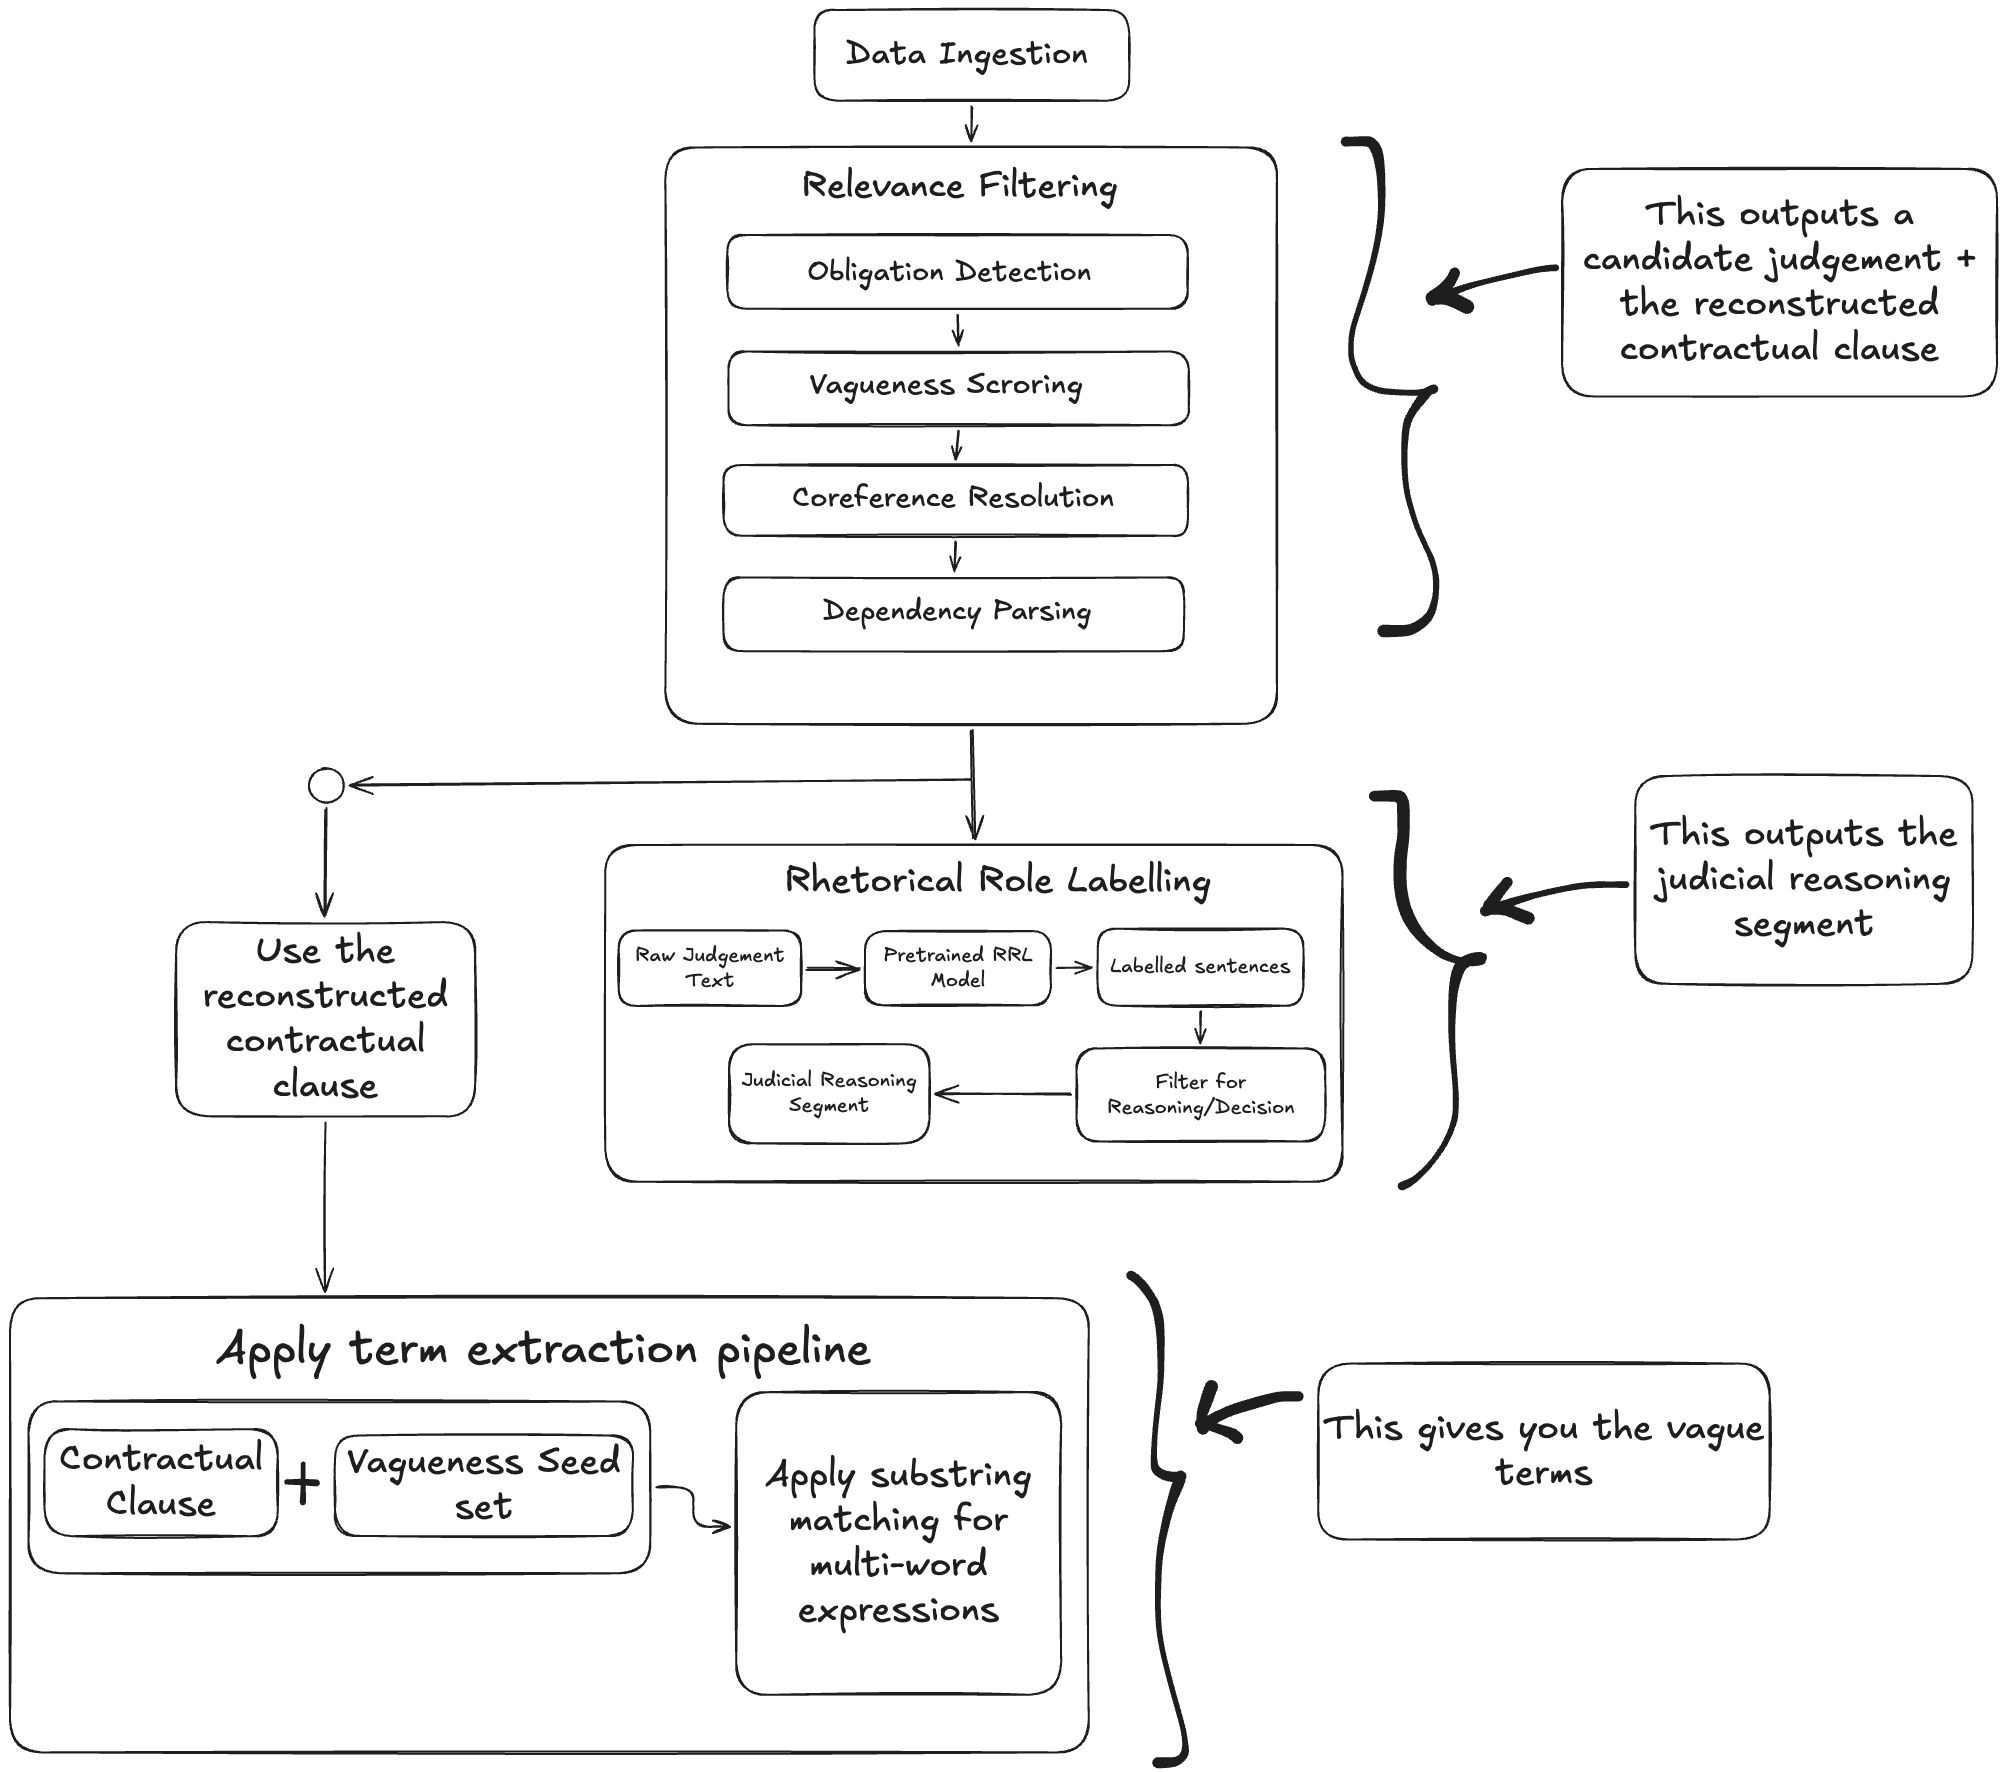

**Step-by-Step walkthrough**

1. Ingest the data. The legal documents/opinions
2. Detect if the input has an obligation (not vague legal obligation). Flag if it contains one or not.
    * If it does, apply ***Relevance Filtering*** to identify if they contain vague legal obligations (`relevance_filter()`)
    * Compute the probability of vagueness scoring (`score_vagueness()`)
    * Identify and isolate sentences that contain quoted contractual clauses (`detect_quoted_clauses()`)
    * Apply **coreference resolution** to identify and pickup the vague obligations leaked over to multiple sentences (`coreference_resolution()`)
    * Use the linked sentences and apply **dependency parsing** to reconstruct the clause (`dependency_parser()`)
3. Use the reconstructed clause, and apply substring matching with a vagueness seed set to extract the vague terms
4. Perform ***Rhetorical Role Labelling*** using a pretrained model. Extract the _decision_ and _reasoning_ chunks.
5. Use the outputs from step 2 (reconstructed contractual clause), step 3 (vague terms), and step 4 (judicial reasoning segment) to contruct the triplet form.

## Relevance Filtering

Given a particular judgement, we need to identify whether it contains a disputed vague obligation term or not.


1. ***Obligation detection:*** Leverage SparkNLP to flag whether a document/opinion contains a vague obligation term or not. Identify the Party + Modal verb + Action

## Environment Setup

Three install groups cover the full pipeline:

1. **SparkNLP stack** — `sparknlp` and `pyspark` for scalable NLP operations.
2. **Hugging Face** — dataset access via the `datasets` library and authenticated hub access via `huggingface_hub`.
3. **Sentence Transformers** — `sentence-transformers` for vagueness similarity scoring.

> ⚠️ The Hugging Face token is pulled from Kaggle secrets. Ensure `HF_READ_DATASETS_TOKEN` is set in your Kaggle secret store before running.

In [1]:
!pip install sparknlp
!pip install spark-nlp
!pip install pyspark
!pip install sentence-transformers
!pip install -q johnsnowlabs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.8/766.8 kB 32.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.3/683.3 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.9/66.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 8.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0,

In [2]:
import sys
sys.path.append('/kaggle/working/packages')

In [3]:
import sparknlp
import os

spark = sparknlp.start()
print(sparknlp.version())

:: loading settings :: url = jar:file:/usr/local/lib/python3.12/dist-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.johnsnowlabs.nlp#spark-nlp_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-91c9d8ec-eff3-4ec1-b12b-8d0a090a114c;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp_2.12;6.4.0 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-s3;1.12.500 in central
	found com.amazonaws#aws-java-sdk-kms;1.12.500 in central
	found com.amazonaws#aws-java-sdk-core;1.12.500 in central
	found commons-logging#commons-logging;1.1.3 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found software.amazon.ion#ion-java;1.0.2 in central
	found joda-time#joda-time;2.8.1 in central
	found com.amazonaws#jmespath-java;1.12.500 in central
	found com.g

6.4.0


In [4]:
from kaggle_secrets import UserSecretsClient
import os
import numpy as np

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_READ_DATASETS_TOKEN")

# Set it as an environment variable so Hugging Face libraries find it
os.environ["HF_READ_DATASETS_TOKEN"] = hf_token

# Verify login via huggingface_hub
from huggingface_hub import login
login(token=hf_token)

## Data Loading — Harvard LIL Cold Cases

The dataset is streamed from Hugging Face to avoid loading the full corpus into memory. Only cases with `"contract"` in the `nature_of_suit` field are examined. The first three valid cases are printed as a sanity check.

> **Note:** Many cases tagged with "contract" also carry tort or real property claims. The `detect_obligations()` gate handles this — it filters on the presence of vague obligation language, not just the case type.

In [5]:
from datasets import load_dataset

# load the dataset from HuggingFace: https://huggingface.co/datasets/harvard-lil/cold-cases
dataset = load_dataset(
    "harvard-lil/cold-cases",
    split="train",
    streaming=True
)

# filter out the dataset to only read Contract cases and print the first 3 raw opinion texts
count = 0

for case in dataset:
    nature = case.get("nature_of_suit", "") or "" # read the nature of the case
    if "contract" in nature.lower():
        opinions = case.get("opinions", []) # extract the opinions into a list
        if opinions and opinions[0].get("opinion_text"):
            print(f"CASE: {case.get('case_name', "Unknown")}")
            print(f"COURT: {case.get('court_full_name', "Unknown")}")
            print(f"NATURE: {nature}")
            print(f"TEXT PREVIEW:\n{opinions[0]['opinion_text'][:500]}")
            print("="*100)
            count += 1
    if count==3:
        break

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

CASE: Billie Jo Crigler v. Darrell R. Bailey
COURT: West Virginia Supreme Court
NATURE: Tort, Contract, and Real Property
TEXT PREVIEW:
                             STATE OF WEST VIRGINIA

                           SUPREME COURT OF APPEALS


Billie Jo Crigler,                                                                  FILED
Defendant Below, Petitioner                                                        April 25, 2014
                                                                              RORY L. PERRY II, CLERK
                                                                            SUPREME COURT OF APPEALS
vs
CASE: Thomas F. Basile v. The Calwell Practice, LLC
COURT: West Virginia Supreme Court
NATURE: Tort, Contract, and Real Property
TEXT PREVIEW:
                             STATE OF WEST VIRGINIA
                           SUPREME COURT OF APPEALS

                                                                                  FILED
Thomas F. Basile,          

In [6]:
cuad_deepseek = load_dataset(
    "zenml/cuad-deepseek",
    split="train",
    verification_mode="no_checks"
)

cuad_deepseek[0]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/57.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/7.22M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/7.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26124 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3266 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3266 [00:00<?, ? examples/s]

{'clause': 'If, having used good faith diligent efforts, Affiliate and Network have failed to enter into such an agreement within such ninety (90)-day period, then neither party shall have an obligation to continue such negotiations or enter into an agreement with respect to the New Channels.',
 'clause_with_context': 'eement within ninety (90) days of such notice to include the terms and conditions pursuant to which the New Channels may be distributed by Affiliate. If, having used good faith diligent efforts, Affiliate and Network have failed to enter into such an agreement within such ninety (90)-day period, then neither party shall have an obligation to continue such negotiations or enter into an agreement with respect to the New Channels.   (m) Matter Broadcast. Federal law and FCC regulations require Network to disclose to Affiliate, and the Stations to disclose to their audiences, th',
 'label': 'Rofr/Rofo/Rofn',
 'contract_name': 'TubeMediaCorp_20060310_8-K_EX-10.1_513921_EX-10.

The **clause** column contains the cleaned clauses from the **clause_with_context**. Our task is simple: to extract the role terms (or legal role terms, contractual role terms) from the contractual clause to create a role seed set. The cleaned clause serves the purpose, and provides better computational efficiency while not exposing us to noise that **clause_with_context** may contain.

In [7]:
clause = cuad_deepseek[0]["clause"]
words = clause.split()
capitalized_words = set(w for w in words[1:] if w[0].isupper() and w.isalpha())
capitalized_words

{'Affiliate', 'Network', 'New'}

In [8]:
exclude_set = {
    # common legal and document references
    "Article", "Paragraph", "Schedule", "Exhibit", "Annex", 
    "Addendum", "Appendix", "Recital", "Provision", "Statute", "Regulation", 
    "Directive", "Order", "Decree", "Chapter", "Clause", "Subparagraph", 
    "Subsection", "Part", "Title", "Volume", "Edition", "Code", "Constitution", 
    "Treaty", "Protocol", "Convention", "Charter", "Policy", "Procedure", 
    "Guideline", "Standard", "Framework", "Manual", "Handbook", "Form", "Template", 
    "Document", "Agreement", "Contract", "Indenture", "Instrument", "Deed", "Lease", "License"

    # global jurisdictions and regions
    "Europe", "Asia", "Africa", "London", "Paris", "Tokyo", "Delaware", "Texas", "Florida", "Illinois", 
    "Washington", "Canada", "Mexico", "China", "India", "Germany", "France", "Japan", "UK", "USA", "EU", 
    "UN", "WTO", "OECD", "Middle", "East", "Western", "Eastern", "Northern", "Southern", "Atlantic", 
    "Pacific", "British", "American", "Canadian", "Chinese", "District", "County", "City", "State"

    # Agencies, Regulators & Entities
    "Department", "Agency", "Bureau", "Commission", "Board", "Council", "Authority", "Ministry", "Treasury", 
    "SEC", "IRS", "FTC", "EPA", "FDA", "FCC", "FINRA", "Nasdaq", "NYSE", "Bank", "Association", "Organization", 
    "Foundation", "Institute", "University", "College", "Union", "Federation", "Chamber", "Commerce", 
    "Administration", "Registrar", "Secretary", "Director", "Governor", "President"

    # Time, Measurement & Currencies
    "Year", "Quarter", "Month", "Week", "Day", "Hour", "Minute", "Second", "Fiscal", "Calendar", "Annual", 
    "Biannual", "Quarterly", "Monthly", "Weekly", "Daily", "GMT", "UTC", "EST", "PST", "Dollar", "Euro", 
    "Pound", "Yen", "Cent", "Percentage", "Ratio", "Total", "Net", "Gross", "Acre", "Mile", "Kilogram", 
    "Liter", "Meter", "Square", "Foot", "Inch", "Unit", "Amount"

    # Common "Filler" Capitalized Words in Legal Text
    "Whereas", "Therefore", "Accordingly", "Notwithstanding", "Provided", "Further", "Also", "In", "On", "At", "By", 
    "For", "With", "From", "To", "The", "This", "That", "Such", "Each", "All", "Any", "No", "Either", "Neither", "Both", 
    "Every", "Other", "Same", "Certain", "Individual", "General", "Specific", "Primary", "Secondary", "Total", "Final", 
    "Effective", "Current", "Prior"
}
exclude_set = {word.lower() for word in exclude_set}

In [9]:
# GENERATED BY CLAUDE

from collections import Counter
import re

DEFINED_IN_PARENS  = re.compile(r'\((?:the\s+|as\s+)?"([A-Z][a-zA-Z ]{2,30}?)"\)')
HEREINAFTER        = re.compile(r'(?:hereinafter|herein)\s+(?:referred to|called|known)\s+as\s+"([A-Z][a-zA-Z ]{2,30}?)"', re.IGNORECASE)
ROLE_BEFORE_DEONTIC = re.compile(r'\bthe\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)\s+(?:shall|must|will|may|agrees|covenants|represents|warrants)\b')

EXCLUDE = {
    "agreement", "contract", "section", "exhibit", "schedule", "annex",
    "article", "clause", "appendix", "amendment", "addendum", "hereof",
    "company",  # too generic on its own
} 

ROLE_SUFFIXES = ("or", "ee", "er", "ant", "ent", "ee")

def looks_like_role(w: str) -> bool:
    return (
        any(w.endswith(s) for s in ROLE_SUFFIXES)
        or "party" in w
        or "holder" in w
        or "owner" in w
    )

def extract_roles_structured(text: str, EXCLUDE_SET: set) -> set[str]:
    found = set()
    for pattern in (DEFINED_IN_PARENS, HEREINAFTER, ROLE_BEFORE_DEONTIC):
        for m in pattern.finditer(text):
            term = m.group(1).strip().lower()
            if len(term) > 2 and term not in EXCLUDE_SET:
                found.add(term)
    return found

role_counter1 = Counter()
role_counter2 = Counter()
N = len(cuad_deepseek)  # run on full dataset, not just 100

for item in cuad_deepseek:
    text = item["clause_with_context"]
    role_counter1.update(extract_roles_structured(text, EXCLUDE))
    role_counter2.update(extract_roles_structured(text, exclude_set))

# Two-gate filter: frequency + morphology
legal_contractual_role_seed_set1 = {
    term for term, count in role_counter1.items()
    if count >= 10 and looks_like_role(term)
}

legal_contractual_role_seed_set2 = {
    term for term, count in role_counter2.items()
    if count >= 10 and looks_like_role(term)
}

print(f"Extracted {len(legal_contractual_role_seed_set1)} roles:")
print(sorted(legal_contractual_role_seed_set1))
print()

print("Using the extensive exclude_set: ")
print(f"Extracted {len(legal_contractual_role_seed_set2)} roles:")
print(sorted(legal_contractual_role_seed_set2))
print()

print(f"Uncommon elements: {legal_contractual_role_seed_set2.difference(legal_contractual_role_seed_set1)}")

Extracted 41 roles:
['adviser', 'agent', 'auditing party', 'buyer', 'carrier', 'client', 'consultant', 'contractor', 'customer', 'developer', 'distributor', 'endorser', 'franchisee', 'franchisor', 'indemnified party', 'indemnifying party', 'investment adviser', 'issuer', 'kubient', 'lender', 'licensee', 'licensor', 'manufacturer', 'owner', 'premier', 'promoter', 'provider', 'purchaser', 'recipient', 'reseller', 'seller', 'servicer', 'shipper', 'sponsor', 'supplier', 'supply agreement', 'talent', 'trademark licensor', 'transporter', 'underwriter', 'vendor']

Using the extensive exclude_set: 
Extracted 42 roles:
['adviser', 'agent', 'amendment', 'auditing party', 'buyer', 'carrier', 'client', 'consultant', 'contractor', 'customer', 'developer', 'distributor', 'endorser', 'franchisee', 'franchisor', 'indemnified party', 'indemnifying party', 'investment adviser', 'issuer', 'kubient', 'lender', 'licensee', 'licensor', 'manufacturer', 'owner', 'premier', 'promoter', 'provider', 'purchaser',

**amendment** is not a role term in a clause. So we will proceed with ***legal_contractual_role_seed_set1*** 

From the first 3 cases that have the word **contract** in them, we see that they are also carrying ***tort*** and ***real property***. The data construction pipeline should be able to handle cases where a contract might be just a part of the entire case, and not a full contract in on itself. 

Therefore, `detect_obligations()` will be the real gate that filters cases that contain contracts and most importantly **vague obligations**.

## Vagueness Seed Set

Two lexicons drive the obligation detection logic:

- **`vague_legal_terms`** — a curated list of terms that courts have historically found ambiguous (effort standards, time references, scope qualifiers, industry norms, etc.).
- **`deontic_modals`** — obligation-carrying modal verbs drawn from contract linguistics (mandatory, permissive, and prohibitory registers).

These seed sets are used both for rule-based matching in `detect_obligations()` and as embedding anchors for semantic similarity scoring in `score_vagueness_per_sentence()`.

In [10]:
vague_legal_terms = {
    # Effort & diligence
    "reasonable efforts", "best efforts", "commercially reasonable", "due diligence", 
    "reasonable care", "good faith", "workmanlike manner", "best practices",

    # Time & urgency
    "promptly", "in a timely manner", "as soon as practicable", "without undue delay",
    "for a reasonable period", "termination of this Agreement", "from time to time",
    "periodic", "duration", "seasonable", "business hours",

    # Scope & degree
    "material", "substantial", "limited", "relevant", "related", "generally",
    "appropriate", "similar", "material adverse effect", "material breach",
    "de minimis", "significant", "incidental", "including but not limited to",
    "inter alia", "and/or", "save as otherwise provided",

    # Necessity & discretion
    "necessary", "sole discretion", "need to know", "confidential nature", "adequate",
    "satisfactory", "proper", "intended purpose", "not to be unreasonably withheld",
    "mutual satisfaction", "at its option", "consultation",

    # Industry norms
    "customary", "ordinary course of business", "industry standard", "standard practice",
    "normally", "comparable", "acceptable", "conventional", "fit for purpose",
    "first-class condition", "commercially sensitive",

    # Knowledge & foresight
    "foreseeable", "contemplated", "intended", "anticipated", "applicable",
    "knowledge", "directly or indirectly", "disclosed in confidence",
    "all copies", "survive", "mutual agreement", "substantially similar",
    "reasonable expectations",
}

len(vague_legal_terms)

72

In [11]:
deontic_modals = {
    # Obligations (Mandatory)
    "shall", "must", "is required to", "is obligated to",
    "undertakes to", "agrees to",

    # Discretion & Permissions (Permissive)
    "may", "is entitled to", "has the right to",
    "may, in its sole discretion,","reserves the right to",

    # Prohibitions (Restrictive)
    "shall not", "may not", "must not",
    "is prohibited from", "no party shall",

    # Conditional/Soft Obligations (Often avoided for being vague)
    "will", "should", "expects to",
    "intends to", "strive to",
}

len(deontic_modals)

21

In [12]:
expanded_vague_legal_terms = {
    # ── Effort & diligence ──────────────────────────────────────────────
    "reasonable efforts", "best efforts", "commercially reasonable",
    "due diligence", "reasonable care", "good faith", "workmanlike manner",
    "best practices", "reasonable endeavours", "all reasonable steps",
    "every reasonable effort", "diligent efforts", "reasonable commercial efforts",
    "utmost care", "exercise of judgment", "commercially practicable",
    "economically reasonable", "technically feasible",
    "consistent with good industry practice", "as would a prudent operator",
    "acting reasonably", "using its discretion",

    # ── Time & urgency ──────────────────────────────────────────────────
    "promptly", "in a timely manner", "as soon as practicable",
    "without undue delay", "for a reasonable period",
    "termination of this Agreement", "from time to time", "periodic",
    "duration", "seasonable", "business hours", "within a reasonable time",
    "with all due speed", "expeditiously", "at the earliest opportunity",
    "without unnecessary delay", "within a commercially reasonable period",
    "in due course", "forthwith", "in due time", "on a timely basis",
    "in the near term", "shortly after", "when practicable",
    "upon reasonable notice", "reasonable notice period",

    # ── Scope, degree & quantity ────────────────────────────────────────
    "material", "substantial", "limited", "relevant", "related", "generally",
    "appropriate", "similar", "de minimis", "significant", "incidental",
    "including but not limited to", "inter alia", "and/or",
    "save as otherwise provided", "appreciable", "meaningful", "non-trivial",
    "measurable", "proportionate", "commensurate", "reasonably proportionate",
    "unduly burdensome", "reasonably necessary", "to the extent practicable",
    "to a reasonable extent", "without limitation", "as applicable",
    "where relevant", "as appropriate", "to the extent required",

    # ── Harm, change & threshold ────────────────────────────────────────
    "material adverse effect", "material breach", "material adverse change",
    "material adverse impact", "material adverse consequence",
    "materially and adversely", "substantial impairment", "material disruption",
    "material deviation", "materially prejudice", "disproportionate impact",
    "unreasonable hardship", "undue prejudice", "undue harm", "undue risk",

    # ── Necessity & discretion ──────────────────────────────────────────
    "necessary", "sole discretion", "need to know", "confidential nature",
    "adequate", "satisfactory", "proper", "intended purpose",
    "not to be unreasonably withheld", "mutual satisfaction", "at its option",
    "consultation", "absolute discretion", "unfettered discretion",
    "not to be unreasonably delayed", "not to be unreasonably conditioned",
    "without arbitrary restriction", "reasonably required",
    "reasonably requested", "if deemed appropriate", "as deemed necessary",
    "in its reasonable opinion", "acting in good faith",
    "in its reasonable judgment", "as it sees fit", "as directed",

    # ── Industry norms & quality ────────────────────────────────────────
    "customary", "ordinary course of business", "industry standard",
    "standard practice", "normally", "comparable", "acceptable",
    "conventional", "fit for purpose", "first-class condition",
    "commercially sensitive", "prevailing market practice",
    "generally accepted practice", "market standard",
    "accepted industry norms", "standard market terms",
    "customary market conditions", "in accordance with accepted methods",
    "consistent with past practice", "as is customary",
    "in accordance with best available techniques",
    "reasonable engineering standards", "professionally acceptable",
    "to a professional standard", "of merchantable quality",
    "of satisfactory quality",

    # ── Knowledge, intent & foresight ──────────────────────────────────
    "foreseeable", "contemplated", "intended", "anticipated", "applicable",
    "knowledge", "directly or indirectly", "disclosed in confidence",
    "all copies", "survive", "mutual agreement", "substantially similar",
    "reasonable expectations", "actual knowledge", "constructive knowledge",
    "reasonably should have known", "to the best of its knowledge",
    "as far as it is aware", "reasonably foreseeable",
    "unforeseen circumstances", "unanticipated events",
    "beyond reasonable expectation", "reasonable belief", "bona fide belief",
    "reasonable grounds", "having regard to all circumstances",

    # ── Confidentiality & information ───────────────────────────────────
    "proprietary information", "non-public information",
    "sensitive business information", "trade secrets",
    "sufficiently confidential", "reasonably considered confidential",
    "maintained in confidence", "treated as confidential",
    "in accordance with confidentiality obligations",

    # ── Financial & commercial terms ────────────────────────────────────
    "commercially attractive", "economically viable",
    "commercially justifiable", "at a reasonable price", "fair market value",
    "arm's length", "at prevailing rates", "on reasonable commercial terms",
    "on competitive terms", "at a rate reflecting market conditions",
    "at cost", "without unreasonable mark-up", "reasonable compensation",
    "reasonable fees",

    # ── Survival, agreement & modification ─────────────────────────────
    "notwithstanding the foregoing", "without prejudice to",
    "subject to the foregoing", "except as otherwise agreed",
    "unless otherwise specified", "where not inconsistent", "insofar as",
    "to the fullest extent permitted by law", "as may be amended",
    "as modified from time to time", "by mutual written consent",
}

print(len(expanded_vague_legal_terms))

206


Herein now, we need a way to detect the party present in the contracts. An easier way would be to use **Named Entity Recognition (NER)**, by leveraging models such as [LegalBert](https://huggingface.co/nlpaueb/legal-bert-base-uncased). But that will just add more compute on top of a very compute intensive pipeline.

An even easier and clever approach can be to think of it this way:
- When you have a party mentioned in a contractual clause, they are often referred to at the beginging of a sentence, most often at the beginging of the document, and then have terms such as "The Licensee" or "the Buyer"
- Notice how they are always capitalised, and in mid-sentence
- Knowing this, we can try to use a simple approach by looking for words that are capitalized mid-sentence

**Note:** This needs to be a sentence level check, not a document one.

## Phase 1 — Relevance Filtering

### `detect_obligations`

The primary gate for the pipeline. Given the full opinion text of a case, it:

1. Splits the text into sentences.
2. For each sentence, checks for the presence of at least one **vague legal term** and at least one **deontic modal**.
3. Checks for a **capitalized word mid-sentence** — a heuristic for detecting a named contractual party.
4. Checks for a **bilateral condition** pattern (`if ... shall`, `unless ... must`, etc.) to distinguish genuine contractual obligations from narrative mentions.
5. Requires **at least two distinct capitalized tokens** per sentence as a proxy for two-party involvement.

Sentences that pass all five checks are returned as `valid_sentences`. The function also surfaces the specific vague terms and deontic modals found.

**Party detection rationale:** Full NER (e.g. LegalBERT) would be more precise but is expensive at pipeline scale. Capitalization mid-sentence is a lightweight heuristic that works well for contract language where parties like "the Licensee" or "the Buyer" are consistently capitalized.

In [13]:
import re

In [14]:
# statutory_pattern = re.compile(
# r'(?x)'                                      # Verbose mode for readability
# r'(?:(?:§|§§|¶|¶¶)\s*[a-zA-Z0-9_\-]+)|'       # 1. Section/Paragraph markers with alphanumerics
# r'(?:\b\d+\s+(?:'                            # 2. Hardened Numeric volume systems:
# r'U\.?\s*S\.?\s*C\.?(?:\s*A\.?|\s*S\.?)?|'    #    USC, USCA, USCS
# r'F\.?\s*[23]?d|F\.?\s*Supp(?:\s*[23]?d)?|'   #    F.2d, F.3d, F.Supp
# r'C\.?\s*F\.?\s*R\.?|'                       #    CFR
# r'S\.?\s*Ct\.?|U\.?\s*S\.?|'                 #    S.Ct., U.S.
# r'A\.?L\.?R\.?|Stat\.?'                      #    ALR, Stat.
# r')\b(?:\s+(?:(?:§|§§)\s*)?[a-zA-Z0-9_\-]+)?)|' #  Strict trailing number/section
# r'(?:\b(?:Pub\.?\s*L\.?|Public\s+Law|H\.?\s*R\.?|S\.?\s*B\.?)\b(?:\s+No\.?)?\s*\d+[\d\-]*)' # 3. Bills
# )

# simpler_statutory_pattern = re.compile(
# r'\b(§|Code|Section|Article|Constitution|Statute|Act of \d{4}|'
# r'U\.S\.C\.|W\.Va\. Code|provided by law|mandates that|'
# r'every municipality|any person|no employee|all employers)\b',
# re.IGNORECASE
# )

In [15]:
# Statutory signals — demoted to soft penalty, not hard gate
STATUTORY_PATTERN = re.compile(
    r'\b(§|Code|Section|Article|Constitution|Statute|Act of \d{4}|'
    r'U\.S\.C\.|W\.Va\. Code|provided by law|mandates that|'
    r'every municipality|any person|no employee|all employers)\b',
    re.IGNORECASE
)

In [16]:
# Nominal/passive obligation expressions common in judicial opinion text
OBLIGATION_NOMINAL_PATTERN = re.compile(
    r'\b(obligation to|duty to|requirement to|requirement that|'
    r'responsible for|liability for|right to|entitled to|'
    r'bound to|bound by|subject to)\b',
    re.IGNORECASE
)

In [17]:
# Word-boundary safe matching for short/noisy modals
DEONTIC_PATTERN = re.compile(
    r'\b('
    # Prohibitions first (longer phrases, must precede their substrings)
    r'shall\s+not|may\s+not|must\s+not|'
    r'is\s+prohibited\s+from|was\s+prohibited\s+from|no\s+party\s+shall|'
    # Obligations
    r'shall(?!\s+not)|must(?!\s+not)|'
    r'is\s+required\s+to|was\s+required\s+to|'
    r'is\s+obligated\s+to|was\s+obligated\s+to|'
    r'undertakes\s+to|undertook\s+to|agrees\s+to|agreed\s+to|'
    # Permissions — "may" only when followed by a verb, not a date/proper noun
    # Negative lookahead: not followed by digit or uppercase (month + date pattern)
    r'may(?!\s+not)(?!\s+\d)(?!\s+[A-Z][a-z]+\s+\d)(?!\s+be\s+broadly)|'
    r'is\s+entitled\s+to|was\s+entitled\s+to|'
    r'has\s+the\s+right\s+to|had\s+the\s+right\s+to|'
    r'reserves\s+the\s+right\s+to|'
    # Soft obligations — "will" only when not referring to a legal will document
    # require lowercase context or followed by a verb
    r'(?<![Aa]\s)(?<![Hh]is\s)(?<![Hh]er\s)(?<![Tt]he\s)will(?!\s+substitute|\s+such)'
    r'(?=\s+(?:be|have|not|also|then|thereafter|instead|further|continue|remain|result))|'
    r'should(?=\s+(?:be|have|not|also|include|consider|apply|result|reflect))|'
    r'expects\s+to|intends\s+to|strive\s+to'
    r')',
    re.IGNORECASE
)

In [18]:
# High-specificity vague terms only — remove general adjectives
# Keep only terms that are vague specifically in a CONTRACTUAL OBLIGATION context
CONTRACTUAL_VAGUE_TERMS = {
    # Effort standards — these are the core
    "reasonable efforts", "best efforts", "commercially reasonable",
    "reasonable endeavours", "all reasonable steps", "diligent efforts",
    "reasonable commercial efforts", "commercially practicable",
    "economically reasonable", "technically feasible",
    "consistent with good industry practice", "as would a prudent operator",
    "acting reasonably", "reasonable care", "due diligence",
    "good faith", "workmanlike manner", "best practices",
    "utmost care", "reasonable commercial efforts",

    # Time standards
    "promptly", "in a timely manner", "as soon as practicable",
    "without undue delay", "within a reasonable time", "forthwith",
    "expeditiously", "at the earliest opportunity",
    "without unnecessary delay", "within a commercially reasonable period",
    "upon reasonable notice", "reasonable notice period",
    "in due course", "on a timely basis",

    # Harm thresholds — specific compound phrases only, not bare "material"
    "material adverse effect", "material adverse change",
    "material adverse impact", "material breach",
    "materially and adversely", "material disruption",
    "undue prejudice", "undue harm", "undue risk",
    "unreasonable hardship", "unduly burdensome",

    # Discretion standards — specific phrases only
    "sole discretion", "absolute discretion", "unfettered discretion",
    "not to be unreasonably withheld", "not to be unreasonably delayed",
    "not to be unreasonably conditioned", "in its reasonable judgment",
    "in its reasonable opinion", "reasonable satisfaction",
    "mutual satisfaction", "as it sees fit",

    # Industry/quality standards
    "industry standard", "standard practice", "customary",
    "ordinary course of business", "prevailing market practice",
    "generally accepted practice", "market standard",
    "accepted industry norms", "fit for purpose",
    "of merchantable quality", "of satisfactory quality",
    "first-class condition", "to a professional standard",
    "consistent with past practice",

    # Financial vagueness — specific phrases only
    "fair market value", "arm's length", "at prevailing rates",
    "on reasonable commercial terms", "reasonable compensation",
    "reasonable fees", "without unreasonable mark-up",

    # Knowledge hedges — specific phrases only, not bare "knowledge"
    "to the best of its knowledge", "as far as it is aware",
    "reasonably should have known", "constructive knowledge",
    "actual knowledge", "bona fide belief", "reasonable belief",
    "reasonable grounds",

    # Confidentiality
    "commercially sensitive", "reasonably considered confidential",
    "sufficiently confidential", "need to know",

    # Obligation nominals that are contractually specific
    "reasonably required", "reasonably necessary",
    "reasonable requirement", "reasonable expectations",
}

In [19]:
def detect_obligations(opinion_text: str) -> dict:
    """Check whether an opinion text contains contractual obligations with vague terms.

    Applies five sequential checks per sentence:
    1. Presence of at least one term from the vague_legal_terms seed set.
    2. Presence of at least one deontic modal.
    3. At least one capitalized word mid-sentence (party heuristic).
    4. A bilateral condition pattern (conditional + modal).
    5. At least two distinct capitalized tokens (two-party proxy).

    Args:
        opinion_text (str): The full opinion text of a legal case.

    Returns:
        dict: A result dict with keys:
            - "status" (bool): True if any valid sentences were found.
            - "valid_sentences" (list[str]): Sentences that passed all checks.
            - "vague_terms" (list[str]): All matched vague terms across valid sentences.
            - "deontic_modals" (list[str]): All matched modals across valid sentences.
            If status is False, only {"status": False} is returned.
    """

    # split the entire opinion text into individual sentences
    sentences = re.split(r'(?<=[.!?])\s+', opinion_text)
    # print(sentences)

    # check if any of the vague terms in the list are present in each sentence of the opinion text and store them in a list
    vague_terms_in_opinion_text, deontic_modals_in_opinion_text = [], []
    valid_sentences = []
    # matched_roles_found = []

    # Obligation indicators that appear in judicial narration of contract disputes
    # Broader than deontic_modals — covers past tense / passive judicial language
    # OBLIGATION_PATTERNS = re.compile(
    #     r'\b(shall|must|may not|shall not|must not|is required to|was required to|'
    #     r'is obligated to|was obligated to|has the right to|had the right to|'
    #     r'agrees to|agreed to|is entitled to|was entitled to|'
    #     r'is prohibited from|was prohibited from|undertakes to|undertook to)\b',
    #     re.IGNORECASE
    # )

    # Roles lowercase — judicial opinions use them as common nouns
    # ROLE_PATTERN = re.compile(
    #     r'\b(licensor|licensee|buyer|seller|vendor|purchaser|assignor|assignee|'
    #     r'lender|borrower|guarantor|obligor|obligee|employer|employee|'
    #     r'contractor|subcontractor|consultant|franchisor|franchisee|'
    #     r'indemnitor|indemnitee|provider|recipient|customer|supplier|'
    #     r'reseller|agent|affiliate|distributor|sublicensee|party|parties)\b',
    #     re.IGNORECASE
    # )
    
    for sentence in sentences:
        sentence = sentence.strip() # strip off all the whitespaces
        
        # use a scoreboard system to flag valid sentences
        # having a total AND gate can make us lose precious information
        points = 0
        
        vague_terms_in_sentence = [word for word in CONTRACTUAL_VAGUE_TERMS if word in sentence.lower()]
        if vague_terms_in_sentence:
            points += 5
        else:
            continue
           
        # deontic_modals_in_sentence = [modal for modal in deontic_modals if modal in sentence.lower()]
        # if deontic_modals_in_sentence:
        #     points += 5
        # else:
        #     continue
        deontic_modals_hit = DEONTIC_PATTERN.findall(sentence)
        if deontic_modals_hit:
            points += 5
        # no continue here unlike vague term check; keep it nominal, not strict

        if vague_terms_in_sentence and deontic_modals_hit:
            points += 15

        # check if there is a capitalized word mid-sentence
        # words = sentence.split()

        # Check 4: bilateral condition — RELAXED for opinion text
        # Accept: if/unless/provided that + obligation OR obligation alone if role present
        # has_bilateral = bool(re.search(
        #     r'\b(if|unless|provided that|in the event that|when|where|'
        #     r'in the event|upon|subject to)\b.+' + OBLIGATION_PATTERNS.pattern,
        #     sentence, re.IGNORECASE
        # ))

        # Also accept sentences that explicitly name a role + obligation + vague term
        # even without a conditional — covers "the seller was required to use reasonable efforts"
        # has_direct_obligation = bool(OBLIGATION_PATTERNS.search(sentence))

        # if (has_bilateral or has_direct_obligation):
        #     points += 5
        
        # check for two different parties in the clause
        # capitalized_words = set(w for w in words[1:] if w[0].isupper() and w.isalpha())

        # at least one contractual role present (case-insensitive)
        # role_hits = list({m.group(0) for m in ROLE_PATTERN.finditer(sentence)})
        # if role_hits:
        #     points += 5

        # check if the sentence has statutory signals
        # if any(statutory_pattern.finditer(sentence)):
        #     points -= 20
        if STATUTORY_PATTERN.search(sentence):
            points -= 10

        if points > 10:
            valid_sentences.append(sentence)
                
            vague_terms_in_opinion_text.extend(vague_terms_in_sentence)
            deontic_modals_in_opinion_text.extend(deontic_modals_hit)
            # matched_roles_found.extend(role_hits)

    if valid_sentences:
        # print(f"Sentences that have vague terms, deontic modals, and capitalized word mid sentence: ")
        # for sentence in valid_sentences:
        #     print(sentence)

        # print(f"Number of vague terms found in the opinion text: {len(vague_terms_in_opinion_text)}")
        # for items in vague_terms_in_opinion_text:
        #     print(items, end=", ")

        # print(f"Number of deontic modals found in the opinion text: {len(deontic_modals_in_opinion_text)}")
        # for items in deontic_modals_in_opinion_text:
        #     print(items, end=", ")

        return {
            "status": True,
            "opinion_text": opinion_text,
            "valid_sentences": valid_sentences,
            "vague_terms": vague_terms_in_opinion_text,
            "deontic_modals": deontic_modals_in_opinion_text,
            # "matched roles": role_hits
        }
    else:
        # print("Document is not a valid contract")
        return {
            "status": False
        }

## Corpus Scan

Streams through the dataset, applies the contract nature filter, then runs `detect_obligations()` on the first opinion of each case. Valid cases (those that pass the gate) are stored in `valid_cases` with their full opinion text and validity metadata. The loop halts after 20 valid cases are collected.

In [20]:
valid_cases = []

valid_case_count = 0
total_examined_case_count = 0

for case in dataset:
    total_examined_case_count += 1
    
    nature = case.get("nature_of_suit", "") or "" # read the nature of the case
    if "contract" in nature.lower():
        opinions = case.get("opinions", []) # extract the opinions into a list
        if opinions and opinions[0].get("opinion_text"):
            contract_validity = detect_obligations(opinions[0]['opinion_text'])
            if contract_validity["status"]:
                print(f"CASE: {case.get('case_name', "Unknown")} is valid")
                print(f"Cases examined so far: {total_examined_case_count}")
                valid_contract = {
                    "case_name": case.get('case_name', "Unknown"),
                    "court_name": case.get('court_full_name', "Unknown"),
                    "opinion_text": opinions[0]['opinion_text'],
                    "validity": contract_validity
                }
                valid_cases.append(valid_contract)
                valid_case_count += 1
                
    if valid_case_count == 20:
        break

print(f"\nTotal number of cases examined: {total_examined_case_count}")
print(f"Found {valid_case_count} valid cases")

CASE: Michael F. and Mary T. Witteried v. City of Charles Town is valid
Cases examined so far: 59541
CASE: J.A. Street & Assoc., Inc. v. BITCO General Ins. Co. is valid
Cases examined so far: 59976
CASE: Daniel W. Miller and The City of Parkersburg v. Kevin Allman is valid
Cases examined so far: 101272
CASE: Jeremiah Goodwin v. City of Shepherdstown is valid
Cases examined so far: 101700
CASE: Schoolhouse Limited Liability v. Creekside Owners Association is valid
Cases examined so far: 126394
CASE: James E. Jones v. Slotnick is valid
Cases examined so far: 143779
CASE: Laura Goddard v. Tyler Hockman and Emily A. Hockman is valid
Cases examined so far: 152674
CASE: David A. Levine v. Rockwool International A/S, Bjorn Rici Andersen, Jefferson County Prosperity, Inc., Roxul USA, Inc., Daniel Casto, Raymond J. Bruning, and Steven Stolipher is valid
Cases examined so far: 167105
CASE: Robert Rufus v. Greenbrier Sporting Club Development Co. is valid
Cases examined so far: 209900
CASE: Broom

In [21]:
# diagnosting check
def diagnose_case(opinion_text: str):
    sentences = re.split(r'(?<=[.!?])\s+', opinion_text)
    
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
        
        vague_hits = [t for t in expanded_vague_legal_terms if t in sentence.lower()]
        deontic_hits = DEONTIC_PATTERN.findall(sentence)
        nominal_hits = OBLIGATION_NOMINAL_PATTERN.findall(sentence)
        statutory_hit = bool(STATUTORY_PATTERN.search(sentence))
        
        points = 0
        if vague_hits: points += 5
        if deontic_hits: points += 5
        if vague_hits and deontic_hits: points += 15
        if nominal_hits: points += 3
        if statutory_hit: points -= 10
        
        # Show sentences that have EITHER signal — regardless of threshold
        if vague_hits or deontic_hits or nominal_hits:
            print(f"\nPOINTS: {points}")
            print(f"  sentence  : {sentence[:120]}")
            print(f"  vague     : {vague_hits}")
            print(f"  deontic   : {deontic_hits}")
            print(f"  nominal   : {nominal_hits}")
            print(f"  statutory : {statutory_hit}")
            print(f"  PASS      : {points > 10}")


for case in valid_cases:
    diagnose_case(case['validity']['opinion_text'])


POINTS: 5
  sentence  : Witteried, and Joshua Witteried, by counsel
Steven Brett Offutt, appeal the Circuit Court of Jefferson County’s March 1,
  vague     : ['proper', 'related']
  deontic   : []
  nominal   : []
  statutory : False
  PASS      : False

POINTS: 5
  sentence  : The facts and legal
arguments are adequately presented, and the decisional process would not be significantly aided
by o
  vague     : ['adequate', 'significant']
  deontic   : []
  nominal   : []
  statutory : False
  PASS      : False

POINTS: 5
  sentence  : Upon consideration of the standard of review, the briefs, and the record
presented, the Court finds no substantial quest
  vague     : ['substantial']
  deontic   : []
  nominal   : []
  statutory : False
  PASS      : False

POINTS: 5
  sentence  : For these
reasons, a memorandum decision is appropriate under Rule 21 of the Rules of Appellate
Procedure.
  vague     : ['appropriate']
  deontic   : []
  nominal   : []
  statutory : False
  PASS      : Fa

In [22]:
for case in valid_cases:
    print(f"Case name: {case["case_name"]}")
    for sentence in case["validity"]["valid_sentences"]:
        print(sentence)
    print("="*80)

Case name: Michael F. and Mary T. Witteried v. City of Charles Town
Such action may include the City taking control of a property, making repairs and/or
improvements or demolition as it sees fit, and attaching a lien to the property for the amount of
the City’s costs for such action.
Case name: J.A. Street & Assoc., Inc. v. BITCO General Ins. Co.
that all the
Work shall be performed in a good and workmanlike manner[,]” and that Street “shall provide
competent supervision of all phases of the Work and shall cause the Work to be performed with a


       2
         Bitco is represented by lawyers Avrum Levicoff and Edward I.
Case name: Daniel W. Miller and The City of Parkersburg v. Kevin Allman
(c) The exemptions herein granted to an authorized
            emergency vehicle shall apply only when the driver of any said
            vehicle while in motion sounds audible signal by bell, siren, or
            exhaust whistle as may be reasonably necessary, and when the
            vehicle i

## Phase 2 — Vagueness Scoring

### Model Setup

[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) is a lightweight but highly capable sentence embedding model. It is used here to compute semantic similarity between individual case sentences and the vagueness seed set.

The seed set embeddings are computed once and reused across all sentences — this avoids redundant computation during the per-sentence scoring loop.

In [23]:
from sentence_transformers import SentenceTransformer

"""
this will be used to calculate the semantic similarity between the vagueness seed set and each sentences from the valid
sentences that detect_obligations will flag. first, the vagueness seed set will be embedded and then, a per-sentence 
embedding will be used to compute cosine similarity against all seed embeddings, and take the maximum score as the 
vagueness probability
"""

# found at https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# embed the vagueness seed set
vagueness_seed_set_embeddings = model.encode(list(vague_legal_terms))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
type(vagueness_seed_set_embeddings)

numpy.ndarray

In [25]:
def score_vagueness_per_sentence(sentences_list: list,
                                 vague_terms_in_sentence: list,
                                 vagueness_seed_set: np.ndarray =  vagueness_seed_set_embeddings,
                                 threshold: float = 0.6) -> list:
    """Score each sentence for semantic similarity to the vagueness seed set.

    For each sentence, computes a cosine similarity against all seed set embeddings
    and takes the maximum score as the sentence's vagueness probability. This is a
    per-sentence operation — scores are not averaged or aggregated across the case.

    Args:
        sentences_list (list[str]): The valid sentences returned by detect_obligations().
        threshold (float): Minimum cosine similarity score to flag a sentence as
            semantically vague. Defaults to 0.6.

    Returns:
        list[dict]: One entry per sentence, each with:
            - "sentence" (str): The original sentence.
            - "vagueness_score" (float): Maximum cosine similarity to any seed embedding.
            - "passes_threshold" (bool): Whether the score meets the threshold.
    """

    # here, you are taking each sentence from a particular case's valid sentences thagt come in as a list
    # you embed each sentence and then compute the similarity of each sentence to the vagueness seed set
    # take the highest score as the vagueness probability
    # NOTE: you are not computing the vagueness probability against the entire set of sentences of the case; IT IS PER-SENTENCE VAGUENESS SCORING AND SIMILARITY CHECKING

    scored_sentences = [] # stores each scored sentences, its max score, and whether it exceeded the minimum required threshold
    
    for sentence in sentences_list:
        # compute the emebedding for each sentence and its vague terms
        case_sentence_embedding = model.encode(sentence)
        case_vague_terms_in_sentence_embedding = model.encode(vague_terms_in_sentence)

        # compute cosine similarity with the vagueness seed set
        sentence_and_vagueness_seed_set_similarities = model.similarity(case_sentence_embedding, vagueness_seed_set)

        # compute cosine similarity between a sentence at vague terms it contains
        sentence_and_self_contained_vague_terms_similarities = model.similarity(
            case_sentence_embedding,
            case_vague_terms_in_sentence_embedding
        )

        # append score metadata to list
        scored_sentences.append({
            "sentence": sentence,
            "vagueness_score_against_vagueness_seed_set": float(sentence_and_vagueness_seed_set_similarities.max()),
            "vagueness_score_against_selfcontained_vague_terms": float(sentence_and_self_contained_vague_terms_similarities.max()),
            # "passes_threshold": sentence_and_vagueness_seed_set_similarities >= threshold
        })

    return scored_sentences

In [26]:
import random 

random_idx = random.randint(1, 19)
random_case = valid_cases[random_idx]

random_case_sentence_list = random_case["validity"]["valid_sentences"]
random_case_vague_terms = random_case["validity"]["vague_terms"]

random_case_scored_vagueness = score_vagueness_per_sentence(
    sentences_list = random_case_sentence_list,
    vague_terms_in_sentence = random_case_vague_terms
)

for items in random_case_scored_vagueness:
        print(f"Sentence: {items["sentence"]}")
        print(f"Vagueness score against vagueness seed set: {items["vagueness_score_against_vagueness_seed_set"]}")
        print(f"Vagueness score against self-contained vague terms in the sentence: {items["vagueness_score_against_selfcontained_vague_terms"]}")
        # print(f"Passed threshold: {items["passes_threshold"]}")
        print("="*80)

Sentence: (c) The exemptions herein granted to an authorized
            emergency vehicle shall apply only when the driver of any said
            vehicle while in motion sounds audible signal by bell, siren, or
            exhaust whistle as may be reasonably necessary, and when the
            vehicle is equipped with at least one lighted flashing lamp as
            authorized by section twenty-six [§ 17C-15-26], article fifteen
            of this chapter which is visible under normal atmospheric
            conditions from a distance of five hundred feet to the front of
            such vehicle, except that an authorized emergency vehicle
            operated as a police vehicle need not be equipped with or
            display a warning light visible from in front of the vehicle.
Vagueness score against vagueness seed set: 0.19499346613883972
Vagueness score against self-contained vague terms in the sentence: 0.12611024081707


In [27]:
# check the scores for all the cases
for case in valid_cases:
    print(f"CASE NAME: {case["case_name"]}\n")
    sentence_list = case["validity"]["valid_sentences"]
    vague_terms_in_sentence = case["validity"]["vague_terms"]

    # print(f"Number of valid sentences: {len(sentence_list)}")
    # print(f"First sentence: {sentence_list[0] if sentence_list else 'EMPTY'}")
    
    vagueness_scores = score_vagueness_per_sentence(sentence_list, vague_terms_in_sentence)

    for items in vagueness_scores:
        # print(f"Sentence: {items["sentence"]}")
        print(f"Vagueness score against vagueness seed set: {items["vagueness_score_against_vagueness_seed_set"]}")
        print(f"Vagueness score against self-contained vague terms in the sentence: {items["vagueness_score_against_selfcontained_vague_terms"]}")
        print("="*80)
    print("-*-"*20)

CASE NAME: Michael F. and Mary T. Witteried v. City of Charles Town

Vagueness score against vagueness seed set: 0.2717595100402832
Vagueness score against self-contained vague terms in the sentence: 0.025239650160074234
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
CASE NAME: J.A. Street & Assoc., Inc. v. BITCO General Ins. Co.

Vagueness score against vagueness seed set: 0.38555893301963806
Vagueness score against self-contained vague terms in the sentence: 0.3578193783760071
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
CASE NAME: Daniel W. Miller and The City of Parkersburg v. Kevin Allman

Vagueness score against vagueness seed set: 0.19499346613883972
Vagueness score against self-contained vague terms in the sentence: 0.12611024081707
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
CASE NAME: Jeremiah Goodwin v. City of Shepherdstown

Vagueness score against vagueness seed set: 0.40669411420822144
Vagueness score against self-contained v

# Why the Rule-Based Filter is Failing and What to Do Next

## The Core Mismatch

The fundamental problem is not a bug in the code — it is a **structural mismatch between the corpus and the query**. The Harvard COLD Cases dataset is a **narrative corpus**: judicial opinions are a judge's retelling of a contractual dispute, written in expository prose for the purpose of legal reasoning. The filter was designed to find **directive language**: the imperative, present-tense clauses ("shall perform", "must maintain", "is required to") that appear in the original contract document.

These two registers are linguistically distinct. A contract says:

> *"The Contractor shall perform all Work in a workmanlike manner using commercially reasonable efforts."*

A judge describing that same obligation says:

> *"Street failed to meet the standard of care required by the agreement, having undertaken to complete the site preparation in a manner consistent with its professional obligations."*

The deontic modal has disappeared. The vague term survives only in paraphrase. A rule-based filter scanning for "shall" and "commercially reasonable" in the same sentence will miss the judicial sentence almost entirely — and that is exactly what the diagnostic output confirms.

---

## What the Diagnostics Actually Show

After two rounds of tuning across 60k+ cases, the filter has produced fewer than 10 confirmed valid cases. The diagnostic output reveals three failure modes operating simultaneously:

**1. Modal false positives degrading precision.** "May" fires on month names ("May 3, 2011"), "will" fires on the legal document ("executed in a will"), "proper" fires as a generic adverb ("properly granted summary judgment"). The filter is passing sentences that have nothing to do with contractual obligation.

**2. Vague terms firing on procedural language.** Terms like "material", "necessary", "appropriate", "applicable", "substantial", and "proper" are ubiquitous in judicial opinions as standard legal vocabulary — not as markers of contractual vagueness. "Material fact", "appropriate relief", and "applicable standard of review" are procedural phrases, not obligation language. The seed set cannot distinguish between the two uses.

**3. Valid obligation sentences have no deontic modal.** The sentence *"Street undertook to perform its obligations in a manner consistent with the level of skill reasonably required for the business"* contains a genuine vague obligation standard but no modal verb. Judges narrate past contractual performance in past tense, passive voice, and nominal constructions. The AND gate between vague terms and deontic modals is structurally incompatible with this register.

Relaxing the threshold helps at the margins but does not solve the root problem: **the signal you are looking for was never reliably encoded in this corpus in the form you are searching for**.

---

## Why Switching Datasets Alone Does Not Solve It

The natural next move is to abandon Harvard COLD Cases in favour of pre-extracted contract clause datasets — CUAD, LEDGAR, or ContractNLI. These datasets contain the directive language directly: clauses are already segmented, labelled by type, and expressed in the original contractual voice. The extraction problem disappears.

But it immediately introduces a **linking problem**: you no longer have the judicial reasoning that interprets those clauses. A CUAD clause tells you what the obligation says. It tells you nothing about how a court resolved a dispute over what "commercially reasonable" meant in context, which party bore the burden when the standard was ambiguous, or how the vagueness was operationalised at trial. That interpretive reasoning is the thing your downstream reward model actually needs.

The risk of naively linking a CUAD clause to a Harvard case that mentions the same vague term is **hallucinated ground truth**: the judicial reasoning may be discussing an entirely different legal standard, in a different industry, under a different contractual structure, using the same words coincidentally. A triplet constructed this way has the appearance of fidelity without the substance of it.

---

## The Right Next Step: Semantic Retrieval with Domain Constraints

The path forward is to stop treating this as a lexical matching problem and treat it as a **semantic retrieval problem**, structured in three stages.

**Stage 1 — Build a vagueness embedding space.** Extract 50–100 representative clauses from CUAD that are labelled as containing vague obligation standards — termination for convenience clauses, reasonable efforts provisions, material adverse change definitions. Embed these clauses using a legal-domain sentence encoder (e.g. `legal-bert` or `sentence-transformers` fine-tuned on contract text). This gives you a semantic map of what vague obligation language looks like in its native contractual form.

**Stage 2 — Query Harvard COLD Cases semantically.** Rather than scanning for "shall" and "reasonable efforts" as substrings, embed every sentence in the Harvard corpus and retrieve the top-k sentences most similar to the vagueness embedding space. This will surface judicial sentences that are semantically proximate to the obligation language — paraphrases, narrations, and interpretive discussions — regardless of whether they contain a deontic modal.

**Stage 3 — Apply domain and rhetorical constraints.** Two filters then run on the retrieved sentences, neither of which is lexical. First, a **domain constraint**: the retrieved judicial sentence must come from a case whose subject matter matches the domain of the source CUAD clause — a software licence clause should link to a technology contract dispute, not a construction case. Second, a **rhetorical role constraint**: the sentence should fall within the reasoning or holding segment of the opinion, not the procedural history or factual background. Rhetorical role labelling (RRL) models trained on legal text can make this distinction automatically.

The output of this pipeline is a triplet with genuine fidelity: an original contractual clause, a judicial interpretation of that clause or a closely analogous one in the same domain, and a structured link between the two grounded in semantic similarity rather than keyword coincidence.

---

## The Metric Question

The critical open question for this approach is: **how do you verify that the retrieved judicial reasoning is actually interpreting the same legal standard as the source clause, rather than merely using the same vague words in a different context?**

Cosine similarity in embedding space is a necessary but not sufficient condition. Two sentences can be semantically close because they share vocabulary while discussing legally distinct standards. The proposed metric should combine three signals: embedding similarity above a calibrated threshold, domain match between the clause's contract type and the case's subject matter, and rhetorical role classification confirming the sentence is part of interpretive reasoning rather than factual narration. Manual audit of a sample of the top-1000 retrieved sentences before any automated triplet construction is not optional — it is the calibration step that sets the threshold for the automated pipeline.

---

## Summary

The rule-based filter has reached the limits of what lexical matching can do against a narrative corpus. The 20-case yield from 143k documents is not a tuning problem — it is a signal that the approach is structurally mismatched to the task. The next step is to reframe extraction as retrieval: start with pre-labelled clauses from CUAD, embed them into a vagueness semantic space, retrieve semantically proximate sentences from the judicial corpus, and constrain the links by domain and rhetorical role. This preserves the ground truth requirement while making the construction of high-fidelity triplets tractable.

Link to the claude chat used for this can be found [here](https://claude.ai/share/bc243fc5-9ef8-4118-94ae-427028098a53)